# 01 — Elementwise Kernels

Covers Phase 1 of the kernel roadmap:
- `vector_add` — hello world, validates infra
- `activations` — ReLU, GELU, SiLU *(not yet implemented)*
- `fused_elementwise` — chained ops *(not yet implemented)*

**Metric**: GB/s — `(num_tensors × n × bytes × 1e-9) / (ms × 1e-3)`

In [ ]:
# ── Setup: mount Drive and clone / pull the repo ─────────────────────────────
import os
from google.colab import drive

drive.mount("/content/drive")

REPO_URL    = "https://github.com/Bhavikupadhyay/triton-kernels.git"
REPO_BRANCH = "feature/activations"
REPO_DIR    = "/content/drive/MyDrive/triton-kernels"

if os.path.exists(REPO_DIR):
    !git -C {REPO_DIR} fetch
    !git -C {REPO_DIR} checkout {REPO_BRANCH}
    !git -C {REPO_DIR} pull
else:
    !git clone --branch {REPO_BRANCH} {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git rev-parse --abbrev-ref HEAD
!bash scripts/setup_colab.sh

In [8]:
# ── Verify GPU ────────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "Go to Runtime > Change runtime type > GPU"
print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: Tesla T4


In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import triton
from kernels.elementwise.vector_add import vector_add, test_vector_add, benchmark_vector_add
from kernels.elementwise.activations import relu, gelu, silu, test_activations, benchmark_relu, benchmark_gelu, benchmark_silu

print("Imports OK")

## 1. vector_add

**File**: `kernels/elementwise/vector_add.py`  
**PyTorch equivalent**: `a + b`  
**Metric**: GB/s — reads 2 tensors, writes 1 → `(3 × n × bytes × 1e-9) / (ms × 1e-3)`

In [10]:
# ── vector_add: Correctness ───────────────────────────────────────────────────
test_vector_add()

test_vector_add: PASSED


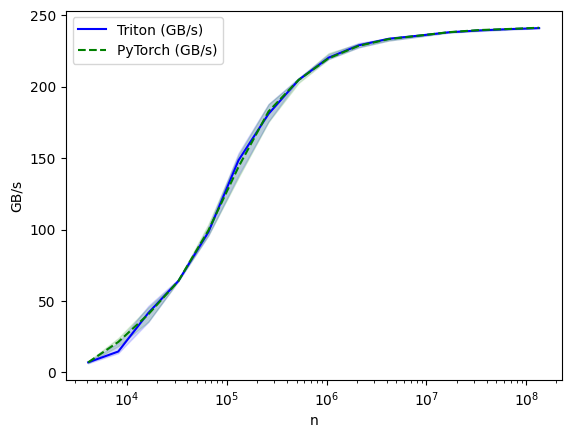

vector_add:
              n  Triton (GB/s)  PyTorch (GB/s)
0        4096.0       7.045872        7.078341
1        8192.0      14.628572       21.333333
2       16384.0      41.654237       40.688742
3       32768.0      63.999998       63.999998
4       65536.0      98.303995       99.497980
5      131072.0     148.495473      143.929718
6      262144.0     181.038673      182.721182
7      524288.0     204.800005      204.800005
8     1048576.0     220.412561      219.980980
9     2097152.0     229.013391      228.680423
10    4194304.0     233.639927      233.397245
11    8388608.0     235.811693      235.794013
12   16777216.0     238.150348      238.236022
13   33554432.0     239.446474      239.701906
14   67108864.0     240.378480      240.479547
15  134217728.0     241.070428      241.335132


<Figure size 640x480 with 0 Axes>

In [11]:
# ── vector_add: Benchmark ─────────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

benchmark_vector_add.run(
    print_data=True,
    show_plots=True,
    save_path="benchmarks/results/elementwise/vector_add_benchmark.png",
)

**Interpretation**

The benchmark shows classic memory-bound scaling behaviour:

- **Small sizes (n ≤ 16K)**: Both implementations are far below peak — kernel launch overhead and L1/L2 cache effects dominate. At n=4K, Triton and PyTorch are both under 15 GB/s.
- **Ramp-up (n = 32K–512K)**: Bandwidth climbs steeply as the working set outgrows cache and HBM transfers take over. This is where memory-bound kernels spend most of their interesting behaviour.
- **Saturation (n ≥ 1M)**: Both plateau at ~241 GB/s, which is near the peak HBM bandwidth of this GPU. The kernel is fully memory-bandwidth-limited here — compute is not the bottleneck.
- **Triton ≈ PyTorch throughout**: Expected. PyTorch's `a + b` also lowers to a simple elementwise CUDA kernel. Our Triton kernel matches it within noise at every size, confirming the implementation is correct and not leaving bandwidth on the table.

**Takeaway**: `vector_add` is about as simple as a GPU kernel gets — it validates that the Triton infrastructure works and that we can saturate HBM bandwidth. The gap at small sizes is launch overhead, not a kernel quality issue.

---
## 2. activations

**File**: `kernels/elementwise/activations.py`
**Operations**: ReLU, GELU (tanh approx), SiLU
**Metric**: GB/s — reads 1 tensor, writes 1 → `(2 × n × bytes × 1e-9) / (ms × 1e-3)`

In [ ]:
# ── activations: Correctness ──────────────────────────────────────────────────
test_activations()

In [ ]:
# ── activations: Benchmarks ───────────────────────────────────────────────────
import os
os.makedirs("benchmarks/results/elementwise", exist_ok=True)

for bench, name in [
    (benchmark_relu, "relu"),
    (benchmark_gelu, "gelu"),
    (benchmark_silu, "silu"),
]:
    bench.run(
        print_data=True,
        show_plots=True,
        save_path=f"benchmarks/results/elementwise/{name}_benchmark.png",
    )

**Interpretation**: *(fill in after running)*

---
## 3. fused_elementwise *(not yet implemented)*